In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 2章演習問題

## (1) 離散時間信号の図示

(a) $x(n)=\Sigma^{N-1}_{k=0}\delta(n-k)$

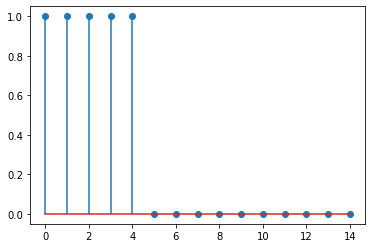

In [2]:
def unit_impluse(n):
    if n == 0:
        delta = 1
    else:
        delta = 0
    return delta

x = []
N = 5
n_samples = 15
for n in range(n_samples):
    xn = 0.0
    for k in range(N):
        xn += unit_impluse(n-k)
    x.append(xn)

markerline, stemlines, baseline = plt.stem(range(n_samples), x, use_line_collection=True)
plt.show()

(b) $x(n)=u_{0}(n)-u_{0}(n-N)$

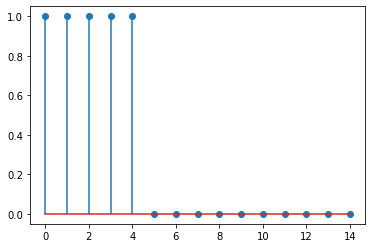

In [3]:
def unit_step(n):
    if n >= 0:
        u = 1
    else:
        u = 0
    return u

x = []
N = 5
for n in range(n_samples):
    x.append(unit_step(n) - unit_step(n-N))

markerline, stemlines, baseline = plt.stem(range(n_samples), x, use_line_collection=True)
plt.show()

(c) $x(n) = r(n) - r(n-N)$

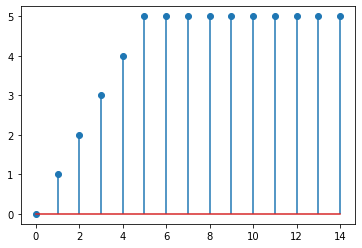

In [4]:
def lamp(n):
    if n >= 0:
        r = n
    else:
        r = 0
    return r

x = []
N = 5
for n in range(n_samples):
    x.append(lamp(n) - lamp(n-N))

markerline, stemlines, baseline = plt.stem(range(n_samples), x, use_line_collection=True)
plt.show()


(d) $x(n)=r(n) - 2r(n-N) + r(n-2N)$

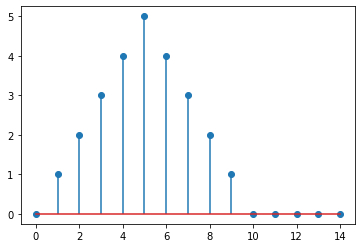

In [5]:
x = []
N = 5
for n in range(n_samples):
    x.append(lamp(n) - 2*lamp(n-N) + lamp(n-2*N))

markerline, stemlines, baseline = plt.stem(range(n_samples), x, use_line_collection=True)
plt.show()

(e) $x(n) = \alpha^{n}u_{0}(n)$

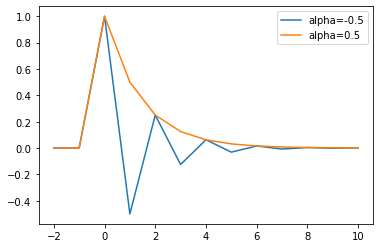

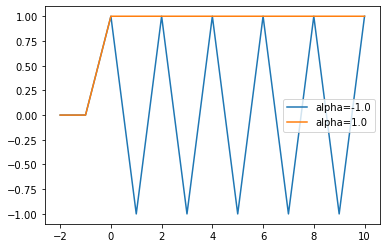

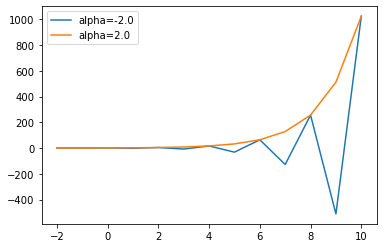

In [6]:
for alpha in [-0.5, 0.5]:
    x = []
    h = [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    for n in h:
        x.append((alpha**n) * unit_step(n))
    plt.plot(h, x, label='alpha='+str(alpha))
    #plt.stem(h, x, use_line_collection=True)
plt.legend()
plt.show()

for alpha in [-1.0, 1.0]:
    x = []
    for n in h:
        x.append((alpha**n) * unit_step(n))
    plt.plot(h, x, label='alpha='+str(alpha))
    #plt.stem(h, x, use_line_collection=True)
plt.legend()
plt.show()
for alpha in [-2.0, 2.0]:
    x = []
    for n in h:
        x.append((alpha**n) * unit_step(n))
    plt.plot(h, x, label='alpha='+str(alpha))
    #plt.stem(h, x, use_line_collection=True)
plt.legend()
plt.show()

(f) $x(n) = r^{n}e^{j\theta n}u_{0}(n)$

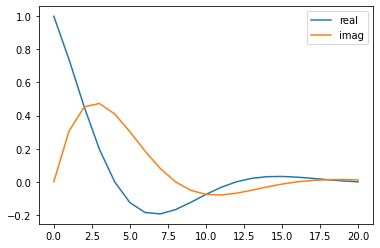

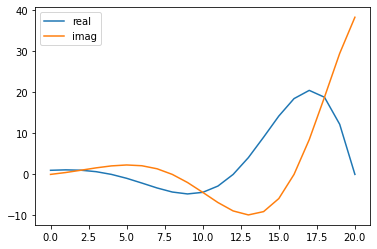

In [7]:
n_samples = 21
theta = np.pi/8.0
r = 0.8
x_r = []
x_i = []
for n in range(n_samples):
    x_r.append(r**n * np.cos(theta * n) * unit_step(n))
    x_i.append(r**n * np.sin(theta * n) * unit_step(n))

plt.plot(range(n_samples), x_r, label='real')
plt.plot(range(n_samples), x_i, label='imag')
plt.legend()
plt.show()

r = 1.2
x_r = []
x_i = []
for n in range(n_samples):
    x_r.append(r**n * np.cos(theta * n) * unit_step(n))
    x_i.append(r**n * np.sin(theta * n) * unit_step(n))

plt.plot(range(n_samples), x_r, label='real')
plt.plot(range(n_samples), x_i, label='imag')
plt.legend()
plt.show()

(g) $x(n) =  {}_{N}C_{n}$

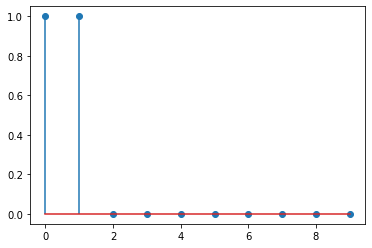

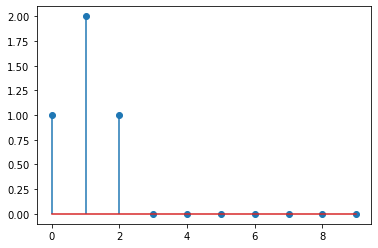

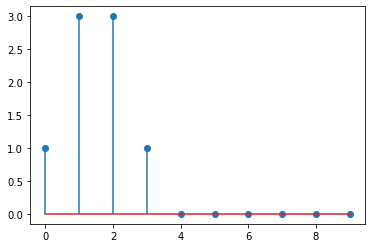

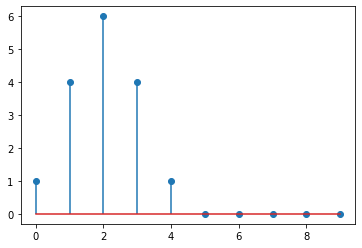

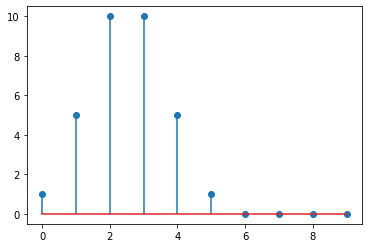

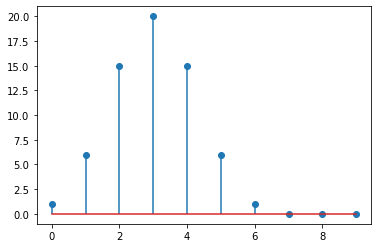

In [20]:
def combination(n, k):
    numerator = 1.0
    denominator = 1.0
    for i in range(k):
        numerator = numerator * (n - i)
        denominator = denominator * (k - i)
    return numerator /denominator


n_samples = 10
for N in [1, 2, 3, 4, 5, 6]:
    x = []
    for n in range(n_samples):
        x.append(combination(N, n))

    markerline, stemlines, baseline = plt.stem(range(n_samples), x, use_line_collection=True)
    plt.show()

## (2) 離散時間フーリエ変換と振幅スペクトル

-----
参考：等比級数の和

初項$a$、公比$r$の等比数列の和は、

(1) 有限数列の場合: $\Sigma_{n=0}^{N-1}ar^{n}=\frac{a(1-r^{N})}{1-r}$, $r\neq 1$

(2) 無限数列の場合: $\Sigma_{n=0}^{\infty}ar^{n}=\frac{a}{1-r}$, $|r| < 1$

-----

(a)
\begin{align*}
X(e^{j\omega}) &= \Sigma_{n=-\infty}^{\infty}\Sigma_{k=0}^{N-1}\delta(n-k)e^{-j\omega n}\\
&= \Sigma_{k=0}^{N-1}e^{-j\omega k}\\
&= \frac{1-e^{-j\omega N}}{1-e^{-j\omega}}\\
\end{align*}

\begin{align}
|X(e^{j\omega})| &= \sqrt{\frac{1-e^{-j\omega N}}{1-e^{-j\omega}}\frac{1-e^{j\omega N}}{1-e^{j\omega}}}
&= \sqrt{\frac{1-\cos{\omega N}}{1-\cos{\omega}}}
\end{align}

(b)

\begin{align}
X(e^{j\omega}) &= \Sigma_{n=-\infty}^{\infty}(u_0(n)-u_0(n-N))e^{-j\omega n}\\
&= \Sigma_{n=0}^{N-1}e^{-j\omega n}\\
&= \frac{1-e^{-j\omega N}}{1-e^{-j\omega}}
\end{align}

\begin{align}
|X(e^{j\omega})| = \sqrt{\frac{1-\cos{\omega N}}{1-\cos{\omega}}}
\end{align}

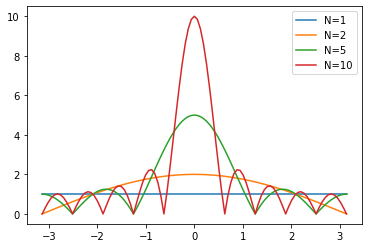

In [9]:
M = 100
omega = np.array([-np.pi + 2*np.pi/M*i for i in range(M+1)])
N = 10
for N in [1, 2, 5, 10]:
    X = np.zeros_like(omega)
    i = 0
    for omg in omega:
        if np.abs(omg) > 1.0e-8:
            X[i] = np.sqrt((1.0 - np.cos(omg * N)) / (1.0 - np.cos(omg)))
        else:
            X[i] = N
        i += 1
    plt.plot(omega, X, label='N='+str(N))
plt.legend()
plt.show()

(c) 収束しない

(d) 

\begin{align}
X(e^{j\omega}) &= \Sigma_{n=-\infty}^{\infty}(r(n)-2r(n-N)+r(n-2N))e^{-j\omega n}\\
&= \Sigma_{n=0}^{N-1}ne^{-j\omega n} + \Sigma_{n=N}^{2N-1}(N-n)e^{-j\omega n}\\
&= \Sigma_{n=0}^{N-1}(e^{-j\omega n}-(N-n)e^{-j\omega (n+N)})\\
&= \Sigma_{n=0}^{N-1}[\{1-(N-n)e^{-j\omega N}\}e^{-j\omega n}]
\end{align}

\begin{align}
|X(e^{j\omega})| &= |\Sigma_{n=0}^{N-1}[\cos{\omega n}-(N-n)\cos{\omega(n+N)}-j\{\sin{\omega n}-(N-n)\sin{\omega}(n+N)\}]|\\
&= \sqrt{(\Sigma_{n=0}^{N-1}\{\cos{\omega n}-(N-n)\cos{\omega(n+N)}\})^2+(\Sigma_{n=0}^{N-1}\{\sin{\omega n}-(N-n)\sin{\omega}(n+N)\})^2}
\end{align}

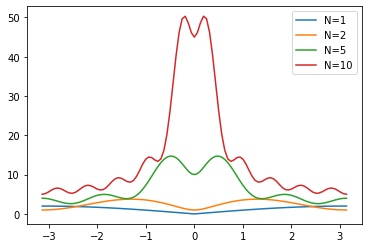

In [10]:
M = 100
omega = np.array([-np.pi + 2*np.pi/M*i for i in range(M+1)])
N = 10
for N in [1, 2, 5, 10]:
    sum_r = 0.0
    sum_i = 0.0
    for n in range(N):
        sum_r += np.cos(omega * n) - (N - n) * np.cos(omega * (n + N))
        sum_i += np.sin(omega * n) - (N - n) * np.sin(omega * (n + N))
    X = np.sqrt(sum_r**2 + sum_i**2)
    plt.plot(omega, X, label='N='+str(N))
plt.legend()
plt.show()

(e)
$|\alpha | < 1$で収束するので、その場合を考える。

\begin{align}
X(e^{j\omega}) &= \Sigma_{n=-\infty}^{\infty}\alpha^{n}u_{0}(n)e^{-j\omega n}\\
&= \Sigma_{n=0}^{\infty}(\alpha e^{-j\omega})^{n}\\
&= \frac{1}{1-\alpha e^{-j\omega}}
\end{align}


\begin{align}
|X(e^{j\omega})| &= |\frac{1}{1-\alpha \cos{\omega} + j\alpha \sin{\omega}}|\\
&= \frac{1}{ \sqrt{ 1+\alpha^{2} -2\alpha \cos{\omega} } }
\end{align}

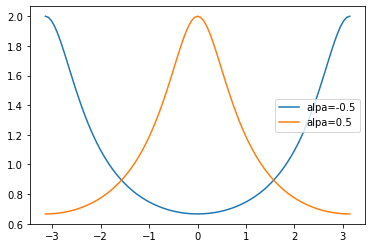

In [11]:
M = 100
omega = np.array([-np.pi + 2*np.pi/M*i for i in range(M+1)])
for alpha in [-0.5, 0.5]:
    X = 1.0 / np.sqrt(1.0 + alpha**2 - 2.0 * alpha * np.cos(omega))
    plt.plot(omega, X, label='alpa='+str(alpha))
plt.legend()
plt.show()

(f)
\begin{align}
X(e^{j\omega}) &= \Sigma_{n=-\infty}^{\infty}r^{n}e^{j\theta n}u_{0}(n)e^{-j\omega n}\\
&= \Sigma_{n=0}^{\infty}(r e^{-j(\omega - \theta)})^{n}\\
&= \frac{1}{1-r e^{-j(\omega - \theta)}}
\end{align}

\begin{align}
|X(e^{j\omega})| &= |\frac{1}{1-r\cos{(\omega - \theta)} + jr \sin{(\omega - \theta)}}|\\
&= \frac{1}{ \sqrt{ 1+r^{2} -2r \cos{(\omega - \theta)} } }
\end{align}

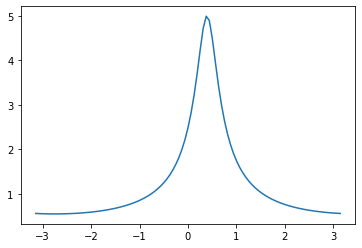

In [12]:
M = 100
omega = np.array([-np.pi + 2*np.pi/M*i for i in range(M+1)])
r = 0.8
thteta = np.pi / 8.0
X = 1.0 / np.sqrt(1.0 + r**2 - 2.0 * r * np.cos(omega-theta))
plt.plot(omega, X)
plt.show()

(g) ?

## (3) $\frac{1}{2\pi}\int_{-\pi}^{\pi}e^{j\omega (n-k)}d\omega=\delta (n-k)$の証明

複素指数関数の定義より、$\int_{-\pi}^{\pi}e^{j\omega (n-k)}d\omega=\int_{-\pi}^{\pi}(\cos\omega(n-k)+j\sin\omega(n-k))d\omega$。

$\cos{m\omega}$と$\sin{m\omega}$は$m\neq 0$のとき$\omega=-\pi$~$\pi$で定積分するとどちらも0、$m=0$では$\int_{-\pi}^{\pi}\cos0d\omega=[\omega]_{\pi}^{\pi}=2\pi$、$\int_{-\pi}^{\pi}\sin0d\omega=0$となる。

したがって、$\frac{1}{2\pi}\int_{-\pi}^{\pi}e^{j\omega (n-k)}d\omega$は$n=k$のとき1、$n \neq k$のとき0で、これは$\delta(n-k)$と一致する。

## (4) 離散時間フーリエ逆変換

(a) 
\begin{align}
\frac{1}{2\pi}\int_{-\pi}^{\pi}(1+\cos{\omega})e^{j\omega n}d\omega &= \frac{1}{2\pi}\int_{-\pi}^{\pi}(1+\frac{e^{j\omega}+e^{-j\omega}}{2})e^{j\omega n}d\omega\\
&= \frac{1}{2\pi}\int_{-\pi}^{\pi}(e^{j\omega n}+\frac{e^{j\omega (n+1)}+e^{j\omega (n-1)}}{2})d\omega\\
&= \delta(n) + \frac{\delta(n+1) + \delta(n-1)}{2}
\end{align}

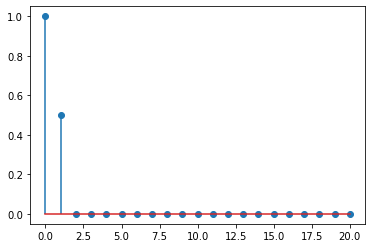

In [13]:
nsamples = 5
x = []
for n in range(n_samples):
    xn = unit_impluse(n) + (unit_impluse(n+1) + unit_impluse(n-1))/2.0
    x.append(xn)

markerline, stemlines, baseline = plt.stem(range(n_samples), x, use_line_collection=True)
plt.show()

(b)
\begin{align}
\frac{1}{2\pi}\int_{-\pi}^{\pi}(1+\cos{\omega})^2e^{j\omega n}d\omega
&= \Sigma_{k=-\infty}^{\infty}(\delta(k) + \frac{\delta(k+1) + \delta(k-1)}{2})(\delta(n-k) + \frac{\delta(n-k+1) + \delta(n-k-1)}{2})\\
&= \frac{3}{2}\delta(n) + \delta(n+1) + \delta(n-1) + \frac{1}{4}\delta(n+2) + \frac{1}{4}\delta(n-2)
\end{align}

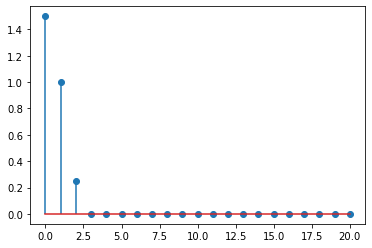

In [14]:
nsamples = 5
x = []
for n in range(n_samples):
    xn = 1.5 * unit_impluse(n) + unit_impluse(n-1) + (unit_impluse(n+2) + unit_impluse(n-2))/4.0
    x.append(xn)

markerline, stemlines, baseline = plt.stem(range(n_samples), x, use_line_collection=True)
plt.show()

(c)
$\cos{\omega}$の離散時間フーリエ逆変換$\frac{\delta(n+1)+\delta(n-1)}{2}$と、推移性から、
\begin{align}
\frac{1}{2\pi}\int_{-\pi}^{\pi}e^{-j\omega /2}\cos{\frac{\omega}{2}}e^{j\omega n}d\omega
&= \frac{\delta(n+1/2-1/2) + \delta(n-1/2-1/2)}{2}\\
&= \frac{\delta(n)+\delta(n-1)}{2}
\end{align}

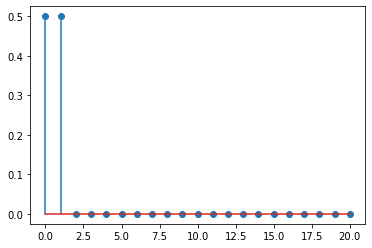

In [15]:
nsamples = 5
x = []
for n in range(n_samples):
    xn = (unit_impluse(n) + unit_impluse(n-1))/2.0
    x.append(xn)

markerline, stemlines, baseline = plt.stem(range(n_samples), x, use_line_collection=True)
plt.show()

(d)
\begin{align}
e^{j(\pi - \omega)/2}\sin{\frac{\omega}{2}} &= e^{-j(\frac{\omega}{2}-\frac{\pi}{2})}\cos{(\frac{\omega}{2}-\frac{\pi}{2})}
\end{align}
変調性と(c)の結果から、
\begin{align}
\frac{1}{2\pi}\int_{-\pi}^{\pi}e^{-j(\frac{\omega}{2}-\frac{\pi}{2})}\cos{(\frac{\omega}{2}-\frac{\pi}{2})}e^{j\omega n}d\omega
&= e^{j\frac{\pi}{2}n}\frac{\delta(n)+\delta(n-1)}{2}
\end{align}

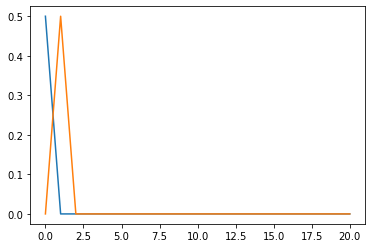

In [16]:
nsamples = 5
xr = []
xi = []
for n in range(n_samples):
    t = (unit_impluse(n) + unit_impluse(n-1))/2.0
    xrn = t * np.cos(np.pi / 2.0 * n)
    xin = t * np.sin(np.pi / 2.0 * n)
    xr.append(xrn)
    xi.append(xin)

plt.plot(range(n_samples), xr)
plt.plot(range(n_samples), xi)
plt.show()

(e)
$\alpha^{n}u_{0}(n)$

(f)
\begin{align}
X(e^{j\omega}) &= \frac{1}{1-re^{-j\theta}e^{-j\omega}}\frac{1}{1-re^{j\theta}e^{-j\omega}}\\
&= \frac{1}{1-re^{-j(\omega + \theta)}}\frac{1}{1-re^{-j(\omega - \theta)}}\\
\end{align}

変調性、たたみこみ、(e)の結果から、

\begin{align}
\frac{1}{2\pi}\int_{-\infty}^{\infty}X(e^{j\omega})e^{j\omega n}d\omega
&= \Sigma_{k=-\infty}^{\infty}e^{-j\theta k}r^{k}u_{0}(k)e^{j\theta (n-k)}r^{n-k}u_{0}(n-k)\\
&= e^{-j\theta n}r^{n}\Sigma_{k=-\infty}^{\infty}u_{0}(k)u_{0}(n-k)\\
&= e^{-j\theta n}r^{n}\Sigma_{k=-0}^{\infty}u_{0}(n-k)\\
\end{align}


## (5) 離散時間フーリエ変換の性質

1. 線形性
\begin{align}
\Sigma_{n=-\infty}^{\infty}\{a_{1}x_{1}(n)+a_{2}x_{2}(n)\}e^{-j\omega n}
&= a_{1}\Sigma_{n=-\infty}^{\infty}x_{1}e^{-j\omega n} + a_{2}\Sigma_{n=-\infty}^{\infty}x_{2}e^{-j\omega n}\\
&= a_{1}X_{1}(e^{j\omega}) + a_{2}X_{2}(e^{j\omega})
\end{align}

\begin{align}
\frac{1}{2\pi}\int_{-\pi}^{\pi}(a_{1}X_{1}(e^{j\omega}) + a_{2}X(e^{j\omega}))e^{j\omega n}d\omega
&= \frac{a_{1}}{2\pi}\int_{-\pi}^{\pi}X_{1}(e^{j\omega})e^{j\omega n}d\omega + \frac{a_{2}}{2\pi}\int_{-\pi}^{\pi}X(e^{j\omega}))e^{j\omega n}d\omega\\
&= a_{1}x_{1}(n) + a_{2}x_{2}(n)
\end{align}

2. 周期性
\begin{align}
X(e^{j(\omega+2\pi k)}) &= \Sigma_{n=-\infty}^{\infty}x(n)e^{-j(\omega + 2\pi k)n}\\
&= \Sigma_{n=-\infty}^{\infty}x(n)e^{-j\omega n}e^{-j2\pi kn}\\
&= \Sigma_{n=-\infty}^{\infty}x(n)e^{-j\omega n}\\
&= X(e^{j\omega})
\end{align}

3. 共役性
\begin{align}
X^{*}(e^{-j\omega}) &= (\Sigma_{n=-\infty}^{\infty}x(n)e^{-j(-\omega)n})^{*}\\
&= \Sigma_{n=-\infty}^{\infty}x^{*}(n)e^{-j\omega n}
\end{align}



4. 対称性
\begin{align}
{\rm Re}[X(e^{-j\omega})]= \Sigma_{n=-\infty}^{\infty}x(n)\cos{-\omega n}
&= \Sigma_{n=-\infty}^{\infty}x(n)\cos{\omega n} = {\rm Re}[X(e^{j\omega n})],\\
{\rm Im}[X(e^{-j\omega})]= -\Sigma_{n=-\infty}^{\infty}x(n)\sin{-\omega n}
&= \Sigma_{n=-\infty}^{\infty}x(n)\sin{\omega n} = -{\rm Im}[X(e^{j\omega n})].
\end{align}
したがって、$X(e^{j\omega})=X^{*}(e^{-j\omega})$

5. 推移
\begin{align}
\Sigma_{n=-\infty}^{\infty}x(n-m)e^{-j\omega n} &= \Sigma_{l=-\infty}^{\infty}x(l)e^{-j\omega (l+m)}\\
&= e^{-j\omega m}\Sigma_{l=-\infty}^{\infty} x(l)e^{-j\omega l}\\
&= e^{-j\omega m}X(e^{j\omega})
\end{align}

6. 変調
\begin{align}
\Sigma_{n=-\infty}^{\infty}e^{j\alpha n}x(n)e^{-j\omega n} &= \Sigma_{n=-\infty}^{\infty}x(n)e^{-j(\omega - \alpha )n}\\
&= X(e^{j(\omega - \alpha )})
\end{align}

7. たたみこみ
\begin{align}
\Sigma_{n=-\infty}^{\infty}\Sigma_{k=-\infty}^{\infty}h(k)x(n-k)e^{-j\omega n} &= \Sigma_{m=-\infty}^{\infty}\Sigma_{k=-\infty}^{\infty}h(k)x(m)e^{-j\omega m+k}\\
&= \Sigma_{k=-\infty}^{\infty}h(k)e^{-j\omega k}\Sigma_{m=-\infty}^{\infty}x(m)e^{-j\omega m}\\
&= H(e^{j\omega})X(e^{j\omega})
\end{align}

8. 積
\begin{align}
\frac{1}{2\pi}\int_{-\pi}^{\pi}Y(e^{j\omega})e^{j\omega n}d\omega &=\frac{1}{2\pi}\int_{-\pi}^{\pi}\frac{1}{2\pi}\int_{-\pi}^{\pi}H(e^{j\theta})X(e^{j(\omega - \theta)}) d\theta e^{j\omega n}d\omega\\
&= \frac{1}{2\pi}\int_{-\pi}^{\pi}\frac{1}{2\pi}\int_{-\pi}^{\pi}H(e^{j\theta})\Sigma_{n=-\infty}^{\infty}e^{j\theta n}x(n) d\theta e^{j\omega n}d\omega\\
&= h(n)\frac{1}{2\pi}\int_{-\pi}^{\pi}X(n)e^{j\omega n}d\omega\\
&= h(n)x(n)
\end{align}

9. 内積
\begin{align}
\frac{1}{2\pi}\int_{-\pi}^{\pi}H(e^{-j\omega})X^{*}(e^{-j\omega})d\omega
&= \frac{1}{2\pi}\int_{-\pi}^{\pi}H(e^{-j\omega})\Sigma_{n=-\infty}^{\infty}x^{*}(n)e^{j\omega n}d\omega \\
&= \Sigma_{n=-\infty}^{\infty}x^{*}(n)\frac{1}{2\pi}\int_{-\pi}^{\pi}H(e^{-j\omega})e^{j\omega n}d\omega \\
&= \Sigma_{n=-\infty}^{\infty}x^{*}(n)h(n)
\end{align}

10. パーセバルの定理
\begin{align}
\Sigma_{n=-\infty}^{\infty}|x(n)|^2 &= \Sigma_{n=-\infty}^{\infty}x(n)(\frac{1}{2\pi}\int_{-\pi}^{\pi}X(e^{j\omega})e^{j\omega n}d\omega )^{*}\\
&= \frac{1}{2\pi}\int_{-\pi}^{\pi}X^{*}(e^{j\omega}) \Sigma_{n=-\infty}^{\infty}x(n)e^{-j\omega n}d\omega\\
&= \frac{1}{2\pi}\int_{-\pi}^{\pi}X^{*}(e^{j\omega}) X(e^{j\omega})d\omega\\
&= \frac{1}{2\pi}\int_{-\pi}^{\pi}|X(e^{j\omega})|^{2}d\omega
\end{align}

## (6) 身近な電子機器の標本化周波数

CDの標本化周波数は44.1kHz.人間の耳に聞こえる音の最大周波数が20kHzなので、その倍の周波数分解能+余裕を持たせている

## (7) 画像、映像の標本化

2次元各々の輝度の周波数に対して、最大周波数の倍以上の周波数で標本化する必要がある。

それ以下の周波数でサンプリングすると、1次元の信号と同様にエイリアシングが発生する。
復元信号に発生する空間的なエイリアシングのことをモアレと呼ぶらしい。縞模様みたいに見える。

https://slidesplayer.net/slide/11549895/

## (8) 標本化周波数$F_s=44.1$\[kHz\]のデジタル信号処理システムにおいて

(a) 標本化周期$T=1/F_s\approx 2.27\times 10^{-2}$ \[ms\]

(b) 標本化角周波数$\Omega_{s} = 2\pi /T \approx 2.77 \times 10^{5}$ \[rad/sec\]

(c) 非正規化周波数$F=441$\[Hz\]に対応する正規化角周波数$\omega=2\pi F / F_{s}\approx 0.628$ \[rad\]